In [16]:
import gymnasium as gym
import torch
import matplotlib.pyplot as plt

In [17]:
class Actor(torch.nn.Module):
    def __init__(self,input_size,action_space):
        super(Actor,self).__init__()
        self.fc1=torch.nn.Linear(input_size,8)
        self.relu=torch.nn.ReLU()
        self.fc2=torch.nn.Linear(8,action_space)
        self.softmax=torch.nn.Softmax(-1)
    
    def forward(self,x):
        x=self.fc1(x)
        x=self.relu(x)
        x=self.fc2(x)
        x=self.softmax(x)
        return x

class Critic(torch.nn.Module):
    def __init__(self,input_size):
        super(Critic,self).__init__()
        self.fc1=torch.nn.Linear(input_size,8)
        self.relu=torch.nn.ReLU()
        self.fc2=torch.nn.Linear(8,1)
    
    def forward(self,x):
        x=self.fc1(x)
        x=self.relu(x)
        x=self.fc2(x)
        return x

In [18]:
class AdvantageActorCritic():
    def __init__(self,env:gym.Env):
        self.env=env
        input_size=self.env.observation_space.shape[0]
        action_space=self.env.action_space.n
        self.actor=Actor(input_size,action_space)
        self.critic=Critic(input_size)
    def run(self,episodes,gamma=0.8,alpha_actor=0.5,alpha_critic=0.5):
        actor_optimizer=torch.optim.Adam(self.actor.parameters(),alpha_actor)
        critic_optimizer=torch.optim.Adam(self.critic.parameters(),alpha_critic)

        stats = {'Actor Loss': [], 'Critic Loss': [], 'Returns': []}

        for episode in range(episodes):
            state=self.env.reset()[0]
            episode_return=0
            done=False
            step_count=0

            while not done:
                state_tensor=torch.FloatTensor(state)

                action_probs=self.actor(state_tensor)
                distribution=torch.distributions.Categorical(action_probs)
                action=distribution.sample()

                next_state,reward,done,_,_=self.env.step(action.item())

                value=self.critic(state_tensor)
                next_value=self.critic(torch.FloatTensor(next_state))

                td_target=reward+gamma*next_value*(1-done)
                advantage=td_target-value

                critic_loss=torch.nn.functional.mse_loss(value,td_target.detach())
                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

                log_prob=distribution.log_prob(action)
                entropy = distribution.entropy()
                actor_loss = -log_prob * advantage.detach() - 0.01 * entropy
                actor_optimizer.zero_grad()
                actor_loss.backward()
                actor_optimizer.step()

                state=next_state
                episode_return+=reward
                step_count+=1

            stats['Actor Loss'].append(actor_loss.item())
            stats['Critic Loss'].append(critic_loss.item())
            stats['Returns'].append(episode_return)
        
        self.env.close()

        return stats

In [19]:
env=gym.make("CartPole-v1")
a2c=AdvantageActorCritic(env)
stats=a2c.run(300,alpha_actor=1e-3, alpha_critic=5e-3)

{'Actor Loss': [0.34928396344184875, 0.1972416639328003, -0.48519787192344666, -1.9194473028182983, 0.029149549081921577, -2.3523261547088623, -1.5181142091751099, -2.3476011753082275, -2.259047746658325, -0.4672076404094696, -1.6705302000045776, -1.6063216924667358, -2.0228071212768555, -1.7015749216079712, -2.575068235397339, -2.24946665763855, -2.1362743377685547, -2.5916054248809814, -1.4993826150894165, -1.8042607307434082, -1.8676161766052246, -1.687669277191162, -1.5490732192993164, -2.12817120552063, -1.8247112035751343, -1.7245723009109497, -1.8839794397354126, -1.4353581666946411, -1.2852122783660889, -2.39200496673584, -1.6455872058868408, -1.484710693359375, -1.702322244644165, -1.1504966020584106, -1.1359758377075195, -1.5367403030395508, -2.2752692699432373, -4.167446613311768, -1.613520622253418, -1.7940349578857422, -1.1456971168518066, -1.4051513671875, -1.2312864065170288, -1.4919010400772095, -1.76156747341156, -1.8721476793289185, -1.4983023405075073, -3.12351822853

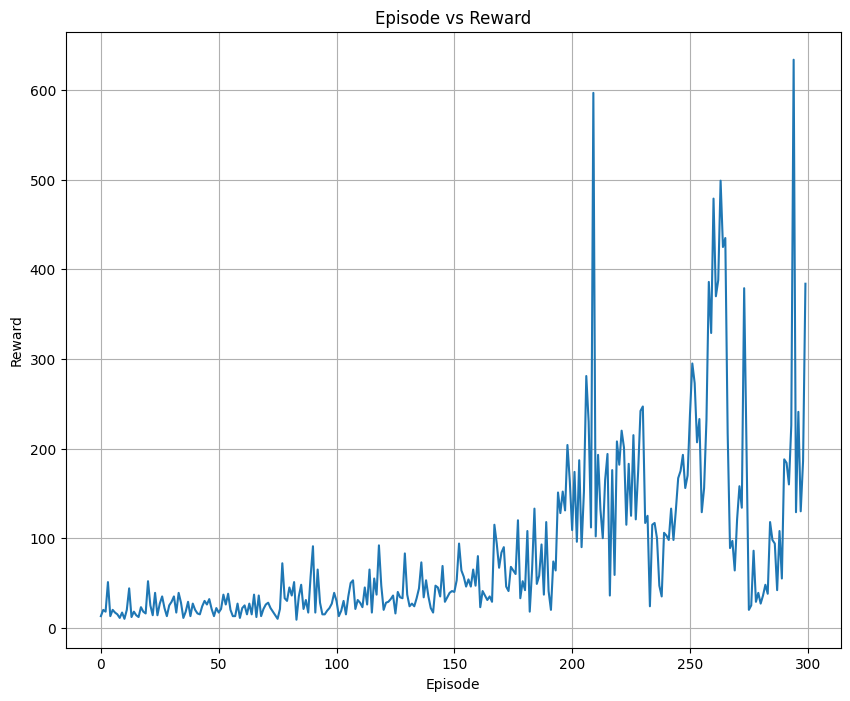

In [20]:
print(stats)

plt.figure(figsize=(10,8))
plt.plot(stats["Returns"])
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Episode vs Reward')
plt.grid(True)
plt.show()

In [22]:
env=gym.make("CartPole-v1",render_mode="human")


for i in range(5):
    state=env.reset()[0]
    episode_return=0
    done=False
    while not done:
        state_tensor=torch.FloatTensor(state)

        action_probs=a2c.actor(state_tensor)
        distribution=torch.distributions.Categorical(action_probs)
        action=distribution.sample()

        next_state,reward,done,_,_=env.step(action.item())

        episode_return+=reward
        state=next_state
    print(f"Episode {i+1} Reward: {episode_return}")

Episode 1 Reward: 374.0
Episode 2 Reward: 230.0
Episode 3 Reward: 114.0
Episode 4 Reward: 108.0
Episode 5 Reward: 314.0
